# Laboratório - Cadeia de Markov

## Ajustando Ambiente

In [ ]:
%%capture
!pip install hmmlearn

## Objetivos de aprendizagem

- Entender as limitações das Redes Bayesianas em análises temporais,
  reconhecendo por que o desdobramento de variáveis ao longo do tempo
  leva à perda de escalabilidade e motivando o uso de modelos dinâmicos
  mais compactos.

- Compreender o mecanismo de transição em Modelos de Markov,
  identificando como a Propriedade de Markov e a hipótese de transições
  estacionárias permitem modelar processos temporais de forma eficiente
  e genérica.

- Aplicar o conceito de Matriz de Transição para prever a evolução de
  estados em séries temporais simples, interpretando os resultados
  probabilísticos obtidos por multiplicação matricial.

- Entender os princípios por trás dos Modelos Ocultos de Markov (HMM),
  diferenciando as camadas de estados ocultos e observações e
  reconhecendo suas aplicações em problemas de inferência com variáveis
  não observáveis

## Motivação

As Redes Bayesianas (RBs) são notavelmente eficientes para modelar a
incerteza e as dependências causais em um **domínio estático**,
utilizando a Fatoração Baseada no Grafo para representar compactamente a
Distribuição de Probabilidade Conjunta. Contudo, essa representação
enfrenta um problema de escalabilidade insuperável quando aplicada a
**séries temporais longas**, como a evolução de um processo financeiro
ou de um conjunto de sintomas.

Para modelar $N$ passos de tempo em uma RB tradicional, seríamos
forçados ao **desdobramento** (*unrolling*), criando $N$ nós
interligados e, consequentemente, uma rede massiva e não genérica. Para
sistemas com duração infinita ou desconhecida, essa abordagem é
inviável, demandando a redefinição completa do grafo e das Tabelas de
Probabilidade Condicional (CPTs) a cada aumento no horizonte de tempo.

**Ilustrando a limitação da rede bayesiana**

Imagine que queremos modelar a previsão do tempo — **se amanhã fará sol
ou chuva** — com base no estado atual e em fatores que se repetem no
tempo. Se quisermos prever o clima para **três dias**, precisaríamos
criar variáveis distintas para cada dia:

$$[\text{Clima}_1, \text{Clima}_2, \text{Clima}_3]$$

Cada variável dependeria da anterior, e as Tabelas de Probabilidade
Condicional (CPTs) cresceriam a cada novo dia. Para prever **10 dias**,
precisaríamos **10 nós** e **9 ligações** — e o grafo precisaria ser
**reconstruído** se quiséssemos 11 dias. Sendo assim, essa abordagem não
é genérica nem eficiente — o modelo precisa ser redesenhado a cada
passo. Finalmente, essa limitação torna a abordagem pouco prática para
processos com duração longa, indefinida ou potencialmente infinita.

Explicação

Considere uma Rede Bayesiana simples para prever o clima (Sol ou Chuva)
onde cada dia depende do dia anterior. Vamos quantificar o custo de
aumentar o horizonte temporal.

**Caso base: 3 dias**

Para modelar 3 dias, precisamos de: \* **Nós:**
$\text{Clima}_1, \text{Clima}_2, \text{Clima}_3 = 3 nós$ \* **Arestas:**
$\text{Clima}_1 \to \text{Clima}_2 \to \text{Clima}_3 = 2 arestas$ \*
**CPTs necessárias:** \* $P(\text{Clima}_1)$: 1 parâmetro livre (prior,
ex: $P(\text{Sol}) = 0.6$) \*
$P(\text{Clima}_2 | \text{Clima}_1)$$: 2 × (2-1) = 2 parâmetros ($$P(\text{Sol}_2|\text{Sol}_1)$\$,
\$$P(\text{Sol}_2|\text{Chuva}_1)$) \*
$P(\text{Clima}_3 | \text{Clima}_2)$: 2 parâmetros \* **Total:** 1 + 2 +
2 = **5 parâmetros**

**Escalonando para 10 dias**

Agora queremos prever 10 dias: - **Nós:** 10 nós distintos -
**Arestas:** 9 conexões sequenciais - **CPTs:** 1 (prior) + 9 × 2 = **19
parâmetros** - **Estrutura do grafo:** precisa ser explicitamente
construída com 10 variáveis

**Horizonte de 11 dias**

Se depois decidirmos estender para 11 dias: - **Reconstrução completa:**
adicionar $\text{Clima}_{11}$, criar nova aresta
$\text{Clima}_{10} \to \text{Clima}_{11}$, definir nova CPT com 2
parâmetros - **Novo total:** 21 parâmetros - **Problema central:** a
topologia da rede **não é reutilizável** — cada horizonte exige uma rede
diferente

**Comparação de custos computacionais**

| Horizonte | Nós | Arestas | Parâmetros CPT | Reuso de estrutura? |
|-----------|-----|---------|----------------|---------------------|
| 3 dias    | 3   | 2       | 5              | Não                 |
| 10 dias   | 10  | 9       | 19             | Não                 |
| 11 dias   | 11  | 10      | 21             | Não                 |
| 100 dias  | 100 | 99      | 199            | Não                 |

Para cada aumento de horizonte, o grafo precisa ser **redesenhado** e as
CPTs **redefinidas**, tornando a abordagem intratável para sequências
longas ou de duração desconhecida.

É nesse ponto que os **Modelos de Markov**, incluindo as **Cadeias de
Markov** e os **Modelos Ocultos de Markov (HMMs)**, tornam-se úteis. Em
vez de construir uma nova variável para cada instante de tempo, uma
Cadeia de Markov representa a evolução do sistema por meio de um estado
genérico, como $\text{Clima}_t$, e de uma **matriz de transição**. Essa
matriz descreve a probabilidade do sistema passar de um estado atual
para um estado futuro:

$$
A =
\begin{bmatrix}
P(\text{Sol}_{t+1} \mid \text{Sol}_t) & P(\text{Chuva}_{t+1} \mid \text{Sol}_t) \\
P(\text{Sol}_{t+1} \mid \text{Chuva}_t) & P(\text{Chuva}_{t+1} \mid \text{Chuva}_t)
\end{bmatrix}
$$

Neste exemplo, cada linha representa o estado atual e cada coluna
representa o próximo estado. Assim, a primeira linha indica as
probabilidades de transição quando o dia atual é de Sol, enquanto a
segunda linha indica as probabilidades de transição quando o dia atual é
de Chuva. Com essa estrutura, podemos prever a distribuição de
probabilidade do clima após $k$ passos multiplicando a distribuição
atual pela matriz de transição elevada a $k$:

$$
P(\text{Clima}_{t+k}) = P(\text{Clima}_t) \cdot A^k
$$

Essa representação se apoia em duas premissas principais:

- **Propriedade de Markov:** o próximo estado depende apenas do estado
  atual, e não de toda a sequência de estados anteriores;

- **Transições estacionárias:** as probabilidades de transição
  permanecem constantes ao longo do tempo.

Dessa forma, a modelagem de um processo temporal deixa de depender da
criação de um novo nó para cada instante de tempo. Com uma
**distribuição inicial** e uma **matriz de transição**, conseguimos
representar a dinâmica do sistema de forma compacta e calcular previsões
para diferentes horizontes temporais por meio de multiplicação
matricial.

Na área de IA, Modelos de Markov são aplicados em diferentes cenários:

- **Reconhecimento de fala:** modela sequências de fonemas e sons para
  identificar palavras em sinais de áudio.
- **Reconhecimento de escrita e gestos:** representa a progressão
  temporal de traços ou movimentos.
- **Biologia computacional:** identifica regiões gênicas ou domínios
  proteicos em sequências biológicas.
- **Robótica:** realiza localização probabilística e rastreamento de
  posição sob incerteza sensorial.
- **Sistemas de recomendação:** prevê próximas ações ou preferências de
  usuários com base em histórico.
- **Aprendizado por reforço:** fundamenta Processos de Decisão de Markov
  (MDPs) e POMDPs em agentes autônomos.

## Cadeia de Markov

Como mencionado, uma **Cadeia de Markov** é uma Rede Bayesiana em forma
de cadeia de comprimento infinito, projetada para rastrear a
probabilidade de um sistema mudar de estado ao longo do tempo. Ele pode
ser pensado como análogo a uma Rede de Bayesiana em forma de cadeia e de
comprimento potencialmente infinito.

O cerne desse modelo de Markov reside na **Propriedade de Markov** (ou
propriedade da falta de memória). Esta propriedade assume que o valor de
uma variável aleatória $W_{i+1}$ (o estado futuro) é condicionalmente
dependente **apenas** do valor da variável imediatamente anterior
$W_{i}$ (o estado atual), sendo independente de todos os estados
passados. Para modelar a evolução de um sistema (como, por exemplo, o
clima dia a dia), o modelo requer apenas dois elementos:

1.  **Distribuição inicial ($P(W_0)$):** descreve a probabilidade de o
    sistema começar em cada estado possível no tempo $t=0$.

2.  **Modelo de transição ($P(W_{i+1} \mid W_i)$):** descreve a
    probabilidade de o sistema passar de um estado atual para um próximo
    estado.

Assume-se, neste exemplo, que o modelo de transição é **estacionário**,
ou seja, que as probabilidades de transição permanecem as mesmas em
todos os passos de tempo.

Com esses dois elementos, é possível calcular a distribuição de
probabilidade dos estados em qualquer momento futuro por meio da
**propagação da distribuição de estados**.

O que é o modelo de transição?

A Matriz de Transição ($A$) é o “motor” do modelo: define como os
estados mudam no tempo, atribuindo probabilidades de ir de um estado
para outro (por exemplo, de “Sol hoje” para “Chuva amanhã”) e aplicando
a Propriedade de Markov, na qual a mudança depende apenas do estado
atual.

### Propagação da distribuição de estados

Em uma Cadeia de Markov observável, podemos prever a distribuição futura
dos estados multiplicando a distribuição atual pela matriz de transição.
Em vez de calcular a distribuição conjunta completa de todos os estados
ao longo do tempo e depois marginalizar as variáveis irrelevantes,
atualizamos apenas a distribuição do estado atual e a avançamos para o
próximo instante.

A intuição por trás do algoritmo é a seguinte:

1.  **Propagação da Probabilidade:** Para calcular a distribuição do
    clima no passo de tempo $i+1$, você pega a distribuição de
    probabilidade conhecida no passo de tempo $i$, $P(W_i)$, e a
    “avança” no tempo usando o Modelo de Transição, $P(W_{i+1}|W_i)$.

2.  **Cálculo Iterativo:** O processo é realizado de forma iterativa:
    você começa com a **Distribuição Inicial** $P(W_0)$.

    - Usa $P(W_0)$ para calcular $P(W_1)$.
    - Usa $P(W_1)$ para calcular $P(W_2)$, e assim por diante.

3.  **Fórmula Matemática:** O algoritmo aplica a Regra da Probabilidade
    Total, reexpressa usando a Regra da Cadeia e a Propriedade de
    Markov:

    $$P(W_{i+1})=\sum_{w_{i}}P(W_{i+1}|w_{i})P(w_{i})$$

Onde a soma é feita sobre todos os estados possíveis $w_i$ no tempo $i$.
Isso permite que a distribuição de probabilidade “flua” para o futuro de
maneira eficiente, passo a passo.

<figure>
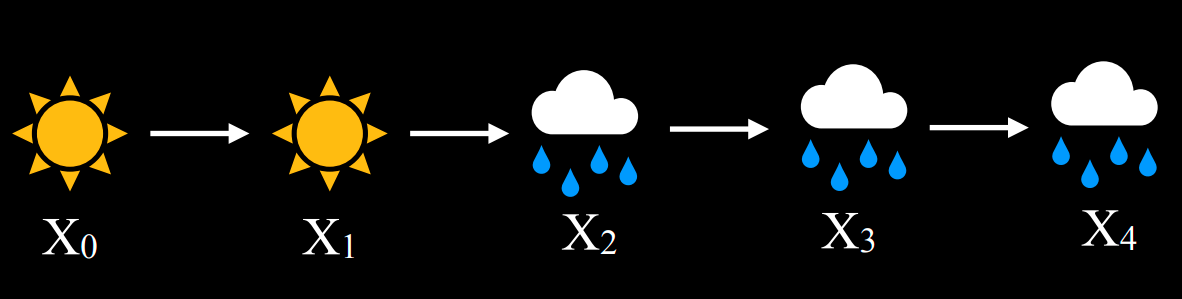
<figcaption aria-hidden="true">image.png</figcaption>
</figure>

### Demonstração de uma Cadeia de Markov

Vamos usar a biblioteca `numpy` para representar a Distribuição Inicial
e a Matriz de Transição como vetores e matrizes, e então aplicar a
multiplicação matricial.

#### Dados do Modelo

- **Estados:** Sol e Chuva.
- **Distribuição Inicial ($P(W_0)$):** Assumimos que no Dia 0, há $80\%$
  de chance de Sol e $20\%$ de chance de Chuva.
- **Matriz de Transição ($A$):** A probabilidade de transitar entre os
  estados.

In [ ]:
import numpy as np

# Definição da Distribuição Inicial (W0)
# P(W0) = [P(Sol), P(Chuva)]
P_W0 = np.array([0.8, 0.2])

# Definição da Matriz de Transição (A)
# A = [[P(Sol|Sol), P(Chuva|Sol)],
#      [P(Sol|Chuva), P(Chuva|Chuva)]]

A = np.array([
    [0.6, 0.4],  # Transições a partir de Sol
    [0.1, 0.9]   # Transições a partir de Chuva
])

print(">> Distribuições Iniciais")
print(f"P(W0) = {P_W0}")
print(f"Matriz de Transição T:\n{A}\n")

### Propagação da distribuição de estados

In [ ]:
# Passo 1: Calcular P(W1)
# P(W1) = P(W0) @ A
# @ é o operador de multiplicação matricial

P_W1 = P_W0 @ A

print(">> Previsão do Dia 1 (P(W1)) ---")
print(f"P(W1) = {P_W1}")
print(f"Probabilidade de Sol no Dia 1: (0.6*0.8 + 0.1*0.2 = {P_W1[0]:.1f})")
print(f"Probabilidade de Chuva no Dia 1: (0.4*0.8 + 0.9*0.2 = {P_W1[1]:.1f})")

In [ ]:
# Passo 2: Calcular P(W2)
# P(W2) = P(W1) @ A
P_W2 = P_W1 @ A

print(">> Previsão do Dia 2")
print(f"P(W2) = {P_W2}")
print(f"Probabilidade de Sol no Dia 2: {P_W2[0]:.4f}")
print(f"Probabilidade de Chuva no Dia 2: {P_W2[1]:.4f}")

In [ ]:
# Passo 3: Previsão de Longo Prazo (Dia 10)
# A mesma lógica se aplica: P(W_t) = P(W_0) @ T^t
# P(W10) = P(W9) @ T ou P(W0) @ (T @ T @ ... 10 vezes)
A_elevado_a_10 = np.linalg.matrix_power(A, 10)
P_W10 = P_W0 @ A_elevado_a_10

print(">> Previsão de Longo Prazo - Dia 10")
print(f"P(W10) = {P_W10.round(4)}")
print(f"Probabilidade de Sol no Dia 10: {P_W10[0]:.4f}")
print(f"Probabilidade de Chuva no Dia 10: {P_W10[1]:.4f}")

Explicação

1.  `import numpy as np` \> Importa a biblioteca `numpy` e a apelida de
    `np`. O `numpy` é essencial para realizar cálculos matemáticos com
    vetores (arrays de 1D) e matrizes (arrays de 2D) de forma eficiente.

2.  `P_W0 = np.array([0.8, 0.2])` \> Cria um vetor numpy (array) para
    representar a **Distribuição Inicial P(W0)**. Este vetor define o
    estado do sistema no tempo $t=0$. \> \* `[0.8, 0.2]` significa que
    há 80% de chance de ser “Sol” (índice 0) e 20% de chance de ser
    “Chuva” (índice 1) no início.

3.  `T = np.array([[0.6, 0.4], [0.1, 0.9]])` \> Cria uma matriz numpy
    (array 2D) para representar a **Matriz de Transição (T)**. Esta
    matriz define a dinâmica do sistema, ou seja,
    $P(\text{Futuro} \mid \text{Atual})$. \> \* **Linha 0 `[0.6, 0.4]`
    (Atual = Sol):** Se hoje está Sol, há 60% de chance de amanhã ser
    Sol (índice 0) e 40% de ser Chuva (índice 1). \> \* **Linha 1
    `[0.1, 0.9]` (Atual = Chuva):** Se hoje está Chuva, há 10% de chance
    de amanhã ser Sol (índice 0) e 90% de ser Chuva (índice 1).

4.  `print("--- Distribuições Iniciais ---")` \> Imprime um cabeçalho de
    texto para organizar a saída.

5.  `print(f"P(W0) = {P_W0}")` \> Imprime a Distribuição Inicial `P_W0`
    que foi definida.

6.  `print(f"Matriz de Transição T:\n{T}\n")` \> Imprime a Matriz de
    Transição `T` que foi definida.

7.  `P_W1 = P_W0 @ T` \> Executa o **Algoritmo Mini-Forward** para o
    primeiro passo. Ele calcula a distribuição do Dia 1 (`P_W1`)
    multiplicando a distribuição atual (`P_W0`) pela Matriz de Transição
    (`T`). O operador `@` realiza a multiplicação de matrizes.

8.  `print("--- Previsão do Dia 1 (P(W1)) ---")` \> Imprime um cabeçalho
    para os resultados do Dia 1.

9.  `print(f"P(W1) = {P_W1}")` \> Imprime o vetor resultante `P_W1` (a
    distribuição de probabilidade no Dia 1).

10. `print(f"Probabilidade de Sol no Dia 1: ...")` \> Imprime o primeiro
    elemento de `P_W1` (a probabilidade de Sol), formatado com uma casa
    decimal, e inclui o cálculo manual que leva a esse resultado.

11. `print(f"Probabilidade de Chuva no Dia 1: ...")` \> Imprime o
    segundo elemento de `P_W1` (a probabilidade de Chuva) e seu cálculo
    manual.

12. `P_W2 = P_W1 @ T` \> Executa o **Algoritmo Mini-Forward** para o
    segundo passo. Ele calcula a distribuição do Dia 2 (`P_W2`)
    multiplicando a distribuição do Dia 1 (`P_W1`) pela Matriz de
    Transição (`T`).

13. `print("--- Previsão do Dia 2 (P(W2)) ---")` \> Imprime um cabeçalho
    para os resultados do Dia 2.

14. `print(f"P(W2) = {P_W2}")` \> Imprime o vetor resultante `P_W2`.

15. `print(f"Probabilidade de Sol no Dia 2: {P_W2[0]:.4f}")` \> Imprime
    a probabilidade de Sol no Dia 2, formatada com quatro casas
    decimais.

16. `print(f"Probabilidade de Chuva no Dia 2: {P_W2[1]:.4f}\n")` \>
    Imprime a probabilidade de Chuva no Dia 2, formatada com quatro
    casas decimais.

17. `T_elevado_a_10 = np.linalg.matrix_power(T, 10)` \> Calcula $T^{10}$
    (a Matriz de Transição elevada à 10ª potência). Isso é feito usando
    a função `matrix_power` da sub-biblioteca de Álgebra Linear
    (`linalg`) do `numpy`.

18. `P_W10 = P_W0 @ T_elevado_a_10` \> Calcula a distribuição de
    probabilidade no Dia 10 (`P_W10`) de forma direta, multiplicando a
    distribuição **inicial** (`P_W0`) pela matriz de transição de 10
    passos (`T_elevado_a_10`).

19. `print("--- Previsão de Longo Prazo (Dia 10) ---")` \> Imprime um
    cabeçalho para o resultado de longo prazo.

20. `print(f"P(W10) = {P_W10.round(4)}")` \> Imprime a distribuição do
    Dia 10 (`P_W10`), com os valores arredondados para 4 casas decimais.

### Interpretação

A simulação demonstra de forma clara a evolução da incerteza ao longo do
tempo, regida pela Matriz de Transição do sistema. O modelo começou no
Dia 0 com uma alta probabilidade de Sol ($\text{80%}$), mas essa
condição inicial otimista foi rapidamente mitigada pela dinâmica interna
do sistema. A transição para o Dia 1 resultou em uma distribuição de
probabilidades perfeitamente uniforme ($\text{50%}$ Sol / $\text{50%}$
Chuva), mostrando que a forte tendência do modelo de transitar para o
estado de Chuva já começou a sobrepor a condição inicial. No Dia 2, essa
tendência se solidifica, empurrando o sistema ainda mais em direção à
Chuva ($\text{65%}$), uma vez que o estado de Chuva possui maior
probabilidade de se manter (0.9) do que o estado de Sol (0.6), ditando o
rumo do sistema no curto prazo.

A verdadeira força do Modelo de Markov é vista no longo prazo. Ao
projetarmos o futuro para o Dia 10, observamos que a distribuição de
probabilidades converge para $\text{20,06%}$ de Sol e $\text{79,94%}$ de
Chuva. Este resultado é praticamente idêntico à Distribuição
Estacionária ($\text{20%}$ Sol / $\text{80%}$ Chuva), o ponto de
equilíbrio matemático do sistema. Este é um conceito crucial: a
influência do estado inicial (os $\text{80%}$ de Sol no Dia 0)
desaparece com o tempo, e o sistema se estabiliza em sua tendência
natural, comprovando que o comportamento médio de longo prazo é
determinado apenas pela matriz de transição.

## Modelo oculto de Markov

Nos exemplos anteriores com Cadeias de Markov, partimos de uma suposição
idealizada: o estado do sistema era **perfeitamente observável**. Para
prever ($P(\text{Sol amanhã})$), precisávamos saber exatamente se
**hoje** estava “Sol” ou “Chuva”. Na realidade, a maioria dos sistemas
complexos não funciona assim. O estado que realmente nos interessa — o
*clima verdadeiro*, o *sentido de uma frase* ou a *doença de um
paciente* — é, na prática, **oculto**. Em vez de observar diretamente o
estado, o que temos são apenas **evidências** ou **sintomas** causados
por ele: o guarda-chuva de alguém, a escolha de uma palavra, o resultado
de um exame.

É justamente esse tipo de situação que o **Modelo Oculto de Markov
(HMM)** foi criado para resolver — permitindo **inferir o estado
invisível** de um sistema a partir de **sequências de observações
ruidosas**.

### O que é o HMM?

O **Modelo Oculto de Markov (HMM)** é um **Modelo de Markov com uma
camada adicional de complexidade**. Ele modela simultaneamente **duas
sequências de variáveis**:

- **Camada Oculta (Estados ($X_t$))** — representa a *“verdade”
  invisível* do sistema. Essa camada segue a mesma dinâmica de um Modelo
  de Markov simples. **Exemplo:** o clima real: {Sunny, Rainy}.

- **Camada Observável (Evidências ($E_t$))** — representa o que podemos
  realmente observar. A evidência no tempo (t) depende apenas do estado
  oculto naquele instante. **Exemplo:** o que observamos: {Umbrella,
  NoUmbrella}.

<figure>
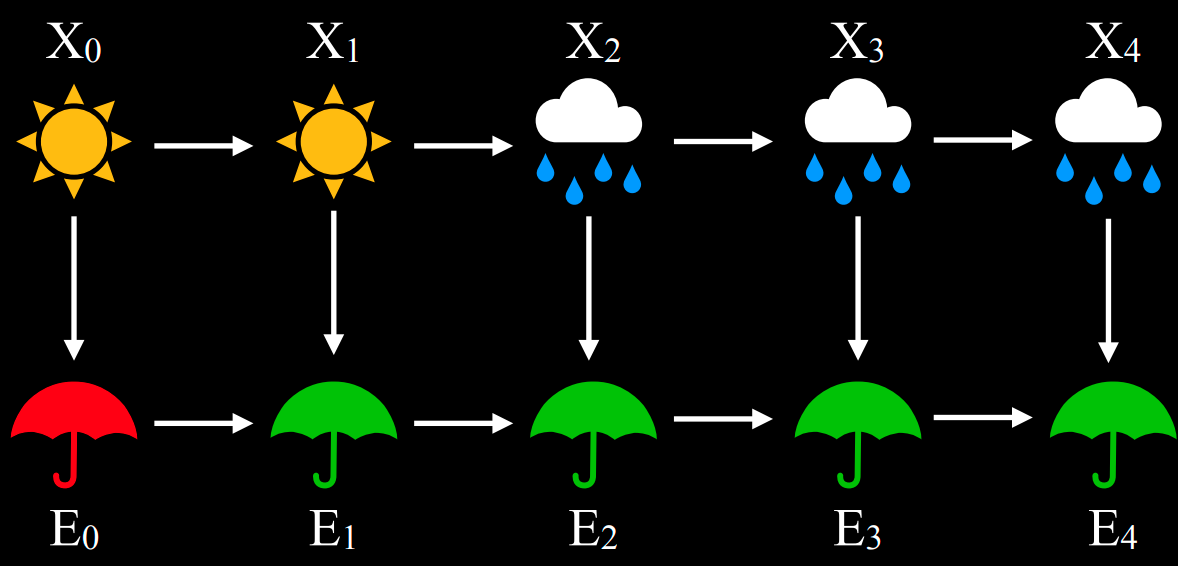
<figcaption aria-hidden="true">image.png</figcaption>
</figure>

Podemos entender que o HMM como uma estrutura que se **“desenrola” no
tempo** em quadros, onde cada quadro representa um momento (t). Logo, em
cada instante, existe:

- um **estado oculto** ($X_t$), que depende apenas do estado anterior
  ($X_{t-1}$) (Propriedade de Markov);
- e uma **evidência observável** ($E_t$), gerada a partir desse estado
  oculto.

Assim, à medida que o tempo avança, o HMM forma uma **cadeia dupla de
dependências** — uma horizontal (entre os estados ocultos) e outra
vertical (entre cada estado e sua observação).

### Componentes de um HMM

Um **Modelo Oculto de Markov (HMM)** é definido por **três conjuntos de
parâmetros**, que descrevem como os estados ocultos evoluem e produzem
observações ao longo do tempo.

**1. Matriz de Transição ((A)):** Define as probabilidades de mudança
entre os estados ocultos. Exemplo: “Qual a probabilidade de amanhã estar
chovendo, dado que hoje está ensolarado?”

**2. Matriz de Emissão ((B)):** Conecta cada estado oculto às
observações visíveis. Exemplo: “Qual a probabilidade de alguém usar
guarda-chuva, dado que o clima é chuvoso?”

**3. Distribuição Inicial (($\pi$)):** Descreve a probabilidade do
sistema começar em cada estado oculto. Portando, sendo o ponto de
partida do processo temporal. Exemplo: “Qual a chance de o primeiro dia
ser ensolarado, chuvoso ou nublado?”

Problemas Fundamentais

Um Modelo Oculto de Markov (HMM) pode ser usado para responder a três
tipos principais de perguntas. O primeiro é o problema de `avaliação`,
que consiste em calcular a probabilidade de uma sequência de observações
ter sido gerada pelo modelo — útil para medir o quanto um HMM explica os
dados. O segundo é o problema de `decodificação`, que busca descobrir
qual é a sequência mais provável de estados ocultos que produziu as
observações, permitindo inferir o que aconteceu “por trás” dos dados
observados. Por fim, o problema de `aprendizagem` envolve estimar os
próprios parâmetros do modelo (as matrizes de transição e emissão) a
partir de dados observacionais, ajustando o HMM automaticamente para
representar melhor o sistema estudado.

- **Avaliação (Evaluation):** Emprega o algoritmo *Forward*. Normalmente
  usado em reconhecimento de padrões, verificação de modelos, análise de
  séries temporais e diagnóstico de sistemas probabilísticos.

- **Decodificação (Decoding):** Utiliza o algoritmo *Viterbi*. Aplicado
  em reconhecimento de fala, bioinformática (anotação de genes), análise
  de linguagem natural e detecção de eventos.

- **Aprendizagem (Learning):** Baseia-se no algoritmo *Baum–Welch* (ou
  *Forward–Backward*). Usado para treinamento de modelos
  probabilísticos, previsão de comportamento e modelagem de processos
  dinâmicos.

### Demonstração do HMM

No código Python abaixo, iremos modelar e implementar o **Modelo Oculto
de Markov (HMM)** que acabamos de discutir, conhecido como o “Mundo do
Guarda-Chuva”. Brevemente, o objetivo é modelar um sistema onde o
**clima real** (o estado oculto, com 3 opções,
`["Sunny", "Rainy", "Foggy"]`) não é visível, e só podemos observar suas
**evidências** (as observações, com 2 opções,
`["Umbrella", "NoUmbrella"]`).

Para fazer isso, usaremos a biblioteca `hmmlearn` e realizaremos as
seguintes etapas:

1.  **Definir os Parâmetros:** Inseriremos manualmente as três matrizes
    essenciais do HMM:
    - π (Probabilidade Inicial): Como o sistema começa (e.g., 40%
      “Sunny”).
    - A (Matriz de Transição): Como o clima (oculto) evolui de um dia
      para o outro.
    - B (Matriz de Emissão): A probabilidade de vermos (ou não) um
      guarda-chuva *dado* o clima oculto.
2.  **Definir Evidências:** Criaremos uma sequência de observações que o
    nosso “observador trancado” viu (ex: \[Guarda-Chuva, Guarda-Chuva,
    Sem Guarda-Chuva, Guarda-Chuva\]).
3.  **Realizar Inferência (Decodificação):** Usaremos o **Algoritmo de
    Viterbi** (`model.decode`) para encontrar a sequência mais provável
    de estados climáticos ocultos que *causou* as nossas observações.
4.  **Realizar Inferência (Previsão):** Com base no último estado
    encontrado, preveremos a distribuição de probabilidade do clima para
    o dia seguinte (aplicando o passo de avanço do Modelo de Markov).

In [ ]:
import numpy as np
from hmmlearn import hmm

# Estados ocultos (W_t): representam o clima real, que não é observado diretamente
states = ["Sunny", "Rainy", "Foggy"]

# Observações possíveis (E_t): o que podemos ver no mundo real
# Neste exemplo, 0 = Umbrella (alguém usando guarda-chuva) e 1 = NoUmbrella
obs = ["Umbrella", "NoUmbrella"]

# Distribuição inicial (π): probabilidade de começar em cada estado
pi = np.array([0.4, 0.3, 0.3])

# Matriz de transição (A): P(W_{t+1} | W_t)
# Cada linha indica a probabilidade de passar do estado atual para o próximo
A = np.array([
    [0.65, 0.25, 0.10],  # de Sunny -> [Sunny, Rainy, Foggy]
    [0.20, 0.65, 0.15],  # de Rainy -> [Sunny, Rainy, Foggy]
    [0.25, 0.35, 0.40],  # de Foggy -> [Sunny, Rainy, Foggy]
])

# Matriz de emissão (B): P(E_t | W_t)
# Liga os estados ocultos (clima real) às observações (guarda-chuva ou não)
B = np.array([
    [0.05, 0.95],  # Sunny  -> P(umbrella)=0.05, P(no)=0.95
    [0.90, 0.10],  # Rainy  -> P(umbrella)=0.90, P(no)=0.10
    [0.40, 0.60],  # Foggy  -> P(umbrella)=0.40, P(no)=0.60
])

In [ ]:
# Inicializa um HMM Multinomial, apropriado para observações discretas (categorias)
# n_components = número de estados ocultos (Sunny, Rainy, Foggy)
# init_params="" impede o modelo de sobrescrever os parámetros definidos manualmente
# n_trials=1 indica que cada observação corresponde a um único evento (não a uma contagem).
model = hmm.MultinomialHMM(n_components=3, init_params="", n_trials=1)

# Explicitly set n_components after initialization
model.n_components = len(states)

# Atribui manualmente os parámetros definidos anteriormente
model.startprob_ = pi        # Distribuição inicial (π)
model.transmat_ = A          # Matriz de transição (A)
model.emissionprob_ = B      # Matriz de emissão (B)
model.n_features = len(obs)  # Informa quantos símbolos de emissão existem

# Cada observação é codificada como um inteiro: 0 = Umbrella, 1 = NoUmbrella
# hmmlearn espera um array 2D de shape (T, 1)
# Umbrella → Umbrella → NoUmbrella → NoUmbrella → NoUmbrella → Umbrella → Umbrella → Umbrella
O_sequence = [
      [1, 0], # (Umbrella = Yes, NoUmbrella = No)
      [1, 0],
      [0, 1],
      [0, 1],
      [0, 1],
      [1, 0],
      [1, 0],
      [1, 0]]

O = O_sequence

In [ ]:
# Decodificação (Viterbi): melhor sequência de estados ocultos
logp, hidden = model.decode(O, algorithm="viterbi")
viterbi_path = [states[i] for i in hidden]
print("Viterbi path:", viterbi_path)

In [ ]:
# Crença sobre os estados em cada tempo
posteriors = model.predict_proba(O)
for t, p in enumerate(posteriors):
    print(f"t={t} -> state={viterbi_path[t]} -> " +
          ", ".join(f"{s}={p[i]:.3f}" for i, s in enumerate(states)))

### Interpretação

Notem que o algoritmo de Viterbi **não** escolheu ‘Rainy’ para toda a
sequência; ele encontrou o caminho dinâmico:
`['Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy']`.
Isso significa que, considerando todas as observações juntas, essa foi a
trajetória global com maior probabilidade conjunta. O Viterbi calculou
que o custo de *transição* (ex: mudar de `Rainy` para `Sunny` no dia 2)
era amplamente compensado pela alta probabilidade de *emissão*
(P(NoUmbrella \| Sunny) = 0.95), que explicava melhor a evidência
“NoUmbrella”.

Já a filtragem (`predict_proba`) mostra a “crença” (probabilidade
posterior) em cada dia, e reage de forma ainda mais dramática. Reparem
que: 1. Quando aparecem observações de “Umbrella” (dias 0, 1), a
probabilidade de “Rainy” é muito alta (chegando a 75.4%). 2. Quando
aparece “NoUmbrella” (dia 2), a crença em “Rainy” **despenca** para
apenas 8.7%, e “Sunny” dispara (chegando a 77.1% no dia 3), pois “Sunny”
explica muito melhor essa evidência. 3. Quando “Umbrella” retorna (dia
5), a crença em “Rainy” **salta de volta** para 82.8%.

Por fim, quando projetamos um passo à frente (Predição), o modelo parte
da última crença (Dia 7: 86.7% ‘Rainy’). A previsão resultante (60.9%
‘Rainy’) é fortemente influenciada pela linha ‘Rainy’ da matriz de
transição (`[0.20, 0.65, 0.15]`), pois o modelo está muito convencido de
que o último estado observado foi ‘Rainy’.

## Exemplo Prático

### Cenário 01 - Processamento de Linguagem Natural (N-gramas)

Em Processamento de Linguagem Natural (PLN), uma tarefa clássica é
prever a próxima palavra de uma frase a partir das palavras anteriores.
Uma forma simples de fazer isso é usando **n-gramas**. Um **n-grama** é
uma sequência de `n` elementos consecutivos em um texto. Esses elementos
geralmente são palavras ou caracteres.

Por exemplo, na frase:

> “o gato dorme”

temos:

- **unigramas:** `"o"`, `"gato"`, `"dorme"`
- **bigramas:** `"o gato"`, `"gato dorme"`
- **trigramas:** `"o gato dorme"`

In [ ]:
import numpy as np
import nltk

from nltk import word_tokenize, bigrams
from hmmlearn import hmm

nltk.download("punkt")
nltk.download("punkt_tab")

#### Definindo um pequeno corpus

O corpus abaixo contém frases simples em português. Ele foi criado
apenas para fins didáticos, permitindo visualizar facilmente as
transições entre palavras.

Em um cenário real, o corpus poderia ser composto por notícias, artigos,
livros, mensagens ou outros conjuntos de textos.

In [ ]:
corpus = [
    "o gato dorme",
    "o gato come",
    "o cachorro dorme",
    "o cachorro late",
    "o gato late",
    "o cachorro come"
]

In [ ]:
tokenized_sentences = []

for sentence in corpus:
    tokens = word_tokenize(sentence.lower(), language="portuguese")
    tokens = ["<s>"] + tokens + ["</s>"]
    tokenized_sentences.append(tokens)

tokenized_sentences

Os tokens <s> e </s> são marcadores artificiais de início e fim de
frase. Eles permitem que o modelo aprenda não apenas as transições entre
palavras, mas também quais palavras tendem a iniciar uma sequência e em
que momento a sequência deve ser encerrada.

#### Extraindo bigramas

Com as frases tokenizadas, podemos extrair os bigramas. Cada bigrama
representa uma transição entre uma palavra atual e a próxima palavra.

In [ ]:
all_bigrams = []

for sentence in tokenized_sentences:
    all_bigrams.extend(list(bigrams(sentence)))

all_bigrams

#### Construindo e inspecionando a matriz de contagens

Nesta etapa, transformamos as palavras do corpus em uma representação
numérica para construir a matriz de contagens dos bigramas.

Primeiro, criamos o **vocabulário**, que reúne todos os tokens únicos
presentes nas sentenças tokenizadas. Em seguida, construímos dois
dicionários auxiliares: `word_to_index`, que converte cada palavra em um
índice numérico, e `index_to_word`, que permite recuperar a palavra a
partir do índice. Esse mapeamento é necessário porque a matriz trabalha
com posições numéricas, não diretamente com texto.

Depois, criamos uma matriz quadrada chamada `count_matrix`, em que as
linhas representam a **palavra atual** e as colunas representam a
**próxima palavra**. Para cada bigrama observado no corpus, localizamos
os índices das duas palavras e incrementamos a célula correspondente.
Assim, a matriz passa a registrar quantas vezes cada transição entre
palavras ocorreu. Por fim, imprimimos apenas as transições com contagem
maior que zero. Essa visualização facilita a interpretação da matriz,
mostrando explicitamente quais pares de palavras foram observados e
quantas vezes cada transição apareceu no corpus.

In [ ]:
vocabulary = sorted(set(token for sentence in tokenized_sentences for token in sentence))

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for word, i in word_to_index.items()}

In [ ]:
n_words = len(vocabulary)
count_matrix = np.zeros((n_words, n_words), dtype=int)

for current_word, next_word in all_bigrams:
    i = word_to_index[current_word]
    j = word_to_index[next_word]
    count_matrix[i, j] += 1

count_matrix

In [ ]:
print(">> Transições observadas:\n")

for i, current_word in enumerate(vocabulary):
    for j, next_word in enumerate(vocabulary):
        if count_matrix[i, j] > 0:
            print(f"{current_word} -> {next_word}: {count_matrix[i, j]}")

#### Convertendo contagens em probabilidades de transição

Para transformar a matriz de contagens em uma **matriz de transição**,
dividimos cada linha pela soma da própria linha.

Assim, cada linha passa a representar uma distribuição de probabilidade:

$$
P(w_{t+1} \mid w_t)
$$

Ou seja, dado que a palavra atual é $w_t$, a linha correspondente
informa a probabilidade de cada possível próxima palavra.

In [ ]:
row_sums = count_matrix.sum(axis=1, keepdims=True)

transition_matrix = np.divide(
    count_matrix,
    row_sums,
    out=np.zeros_like(count_matrix, dtype=float),
    where=row_sums != 0
)

transition_matrix

In [ ]:
print(">> Matriz de transição interpretada:\n")
print("Cada linha representa a palavra atual.")
print("Cada coluna representa uma possível próxima palavra.")
print("Os valores indicam P(próxima palavra | palavra atual).\n")

for i, current_word in enumerate(vocabulary):
    probabilities = transition_matrix[i]

    # Ignora palavras sem transições observadas
    if probabilities.sum() == 0:
        print(f"'{current_word}' não possui próximas palavras observadas no corpus.\n")
        continue

    print(f"Se a palavra atual é '{current_word}', então:")

    for j, next_word in enumerate(vocabulary):
        probability = probabilities[j]

        if probability > 0:
            print(f"  P({next_word} | {current_word}) = {probability:.3f}")

    print()

In [ ]:
def show_next_words(word, top_k=5):
    """
    Mostra as palavras mais prováveis de aparecer depois de uma palavra específica.
    """
    if word not in word_to_index:
        print(f"A palavra '{word}' não está no vocabulário.")
        return

    i = word_to_index[word]
    probabilities = transition_matrix[i]

    sorted_indices = np.argsort(probabilities)[::-1]

    print(f"Próximas palavras mais prováveis depois de '{word}':\n")

    for idx in sorted_indices[:top_k]:
        if probabilities[idx] > 0:
            print(f"{index_to_word[idx]}: {probabilities[idx]:.3f}")

In [ ]:
show_next_words("o")

In [ ]:
show_next_words("cachorro")

In [ ]:
def generate_markov_sentence(
    transition_matrix,
    initial_word="<s>",
    max_words=10,
    seed=42
):
    """
    Gera uma frase usando uma Cadeia de Markov baseada na matriz de transição.

    A geração começa no token inicial `<s>` e continua até encontrar o token
    de fim `</s>` ou atingir o número máximo de palavras.
    """
    rng = np.random.default_rng(seed)

    current_word = initial_word
    sentence = []

    for _ in range(max_words):
        i = word_to_index[current_word]
        probabilities = transition_matrix[i]

        if probabilities.sum() == 0:
            break

        next_index = rng.choice(len(vocabulary), p=probabilities)
        next_word = index_to_word[next_index]

        if next_word == "</s>":
            break

        sentence.append(next_word)
        current_word = next_word

    return " ".join(sentence)

Vamos gerar algumas frases usando diferentes sementes aleatórias. Como o
modelo escolhe a próxima palavra por amostragem probabilística,
diferentes sementes podem produzir frases diferentes.

In [ ]:
for seed in range(5):
    print(f"Frase {seed + 1}: {generate_markov_sentence(transition_matrix, seed=seed)}")

## Key Takeaways

As Redes Bayesianas são poderosas para representar incertezas e relações
causais em domínios estáticos, mas tornam-se rapidamente inviáveis
quando aplicadas a processos temporais longos. A necessidade de
“desdobrar” o grafo ao longo do tempo faz com que o modelo cresça de
forma exponencial e perca generalidade.

Essa limitação é o que motiva o surgimento dos Modelos de Markov, que
trazem uma solução elegante e escalável: representar a dinâmica temporal
com um conjunto fixo de estados e uma única matriz de transição,
independente da duração da sequência observada.

Finalmente, os **Modelos de Markov** também ajudam a compreender a
evolução histórica dos modelos sequenciais em IA. Sua ideia central —
representar sequências por meio de estados e transições — serviu como
uma das bases conceituais para o desenvolvimento das **Redes Neurais
Recorrentes (RNNs)**, cujo princípio era manter um **estado oculto**
capaz de carregar informações dos passos anteriores da sequência.
Diferentemente das Cadeias de Markov simples, que assumem dependência
direta apenas do estado atual, as RNNs buscavam representar um contexto
acumulado ao longo do tempo.

Todavia, as RNNs apresentam limitações importantes. Seu processamento é
sequencial, pois cada passo depende do resultado do passo anterior, o
que torna o treinamento mais lento. Além disso, problemas como o
**desvanecimento dos gradientes** (*vanishing gradients*) dificultam o
aprendizado de dependências longas. Nesse contexto, os **Transformers**
surgem como uma alternativa mais eficiente, baseada no mecanismo de
**atenção**, que permite ao modelo avaliar dinamicamente quais partes da
sequência são mais relevantes para cada previsão.

Assim, enquanto os Modelos de Markov utilizam transições fixas e locais,
os Transformers aprendem relações dependentes do contexto completo.
Alguns autores interpretam esse mecanismo como uma forma de **Cadeia de
Markov condicionada ao contexto**, pois a próxima representação ou
previsão deixa de depender apenas de um estado anterior fixo e passa a
ser influenciada por múltiplos elementos da sequência, ponderados pelo
mecanismo de atenção. Dessa forma, os Transformers podem ser vistos como
uma generalização moderna da ideia de modelar dependências sequenciais,
combinando transições, contexto e aprendizado adaptativo.

## Referências

1.  Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern
    Approach. Prentice Hall.
2.  [Markov Novel
    Writer](https://www.kaggle.com/code/ngongochai/markov-chain-sherlock-holmes)